# Model Inspection

Looking inside the trained model: which weights are saved, and what do the learned filters look like?

## 1. Load the saved file

`torch.save(model.state_dict(), ...)` (in `train.py`) doesn't save a complete model object, just a dictionary with the names and values of every learnable parameter. `torch.load()` reads it back, here just to check the structure: each layer with weights gets a `.weight` and a `.bias` entry, each with the expected shape (e.g. `conv1.weight` = 32 filters x 1 input channel x 3x3).

In [38]:
import sys
sys.path.append("../src")

import torch
from model import CNN

state_dict = torch.load("../models/cnn_handwriting_model.pth", map_location="cpu")

for name, tensor in state_dict.items():
    print(f"{name:20s} {tuple(tensor.shape)}")

conv1.weight         (32, 1, 3, 3)
conv1.bias           (32,)
conv2.weight         (64, 32, 3, 3)
conv2.bias           (64,)
conv3.weight         (128, 64, 3, 3)
conv3.bias           (128,)
fc1.weight           (256, 1152)
fc1.bias             (256,)
fc2.weight           (95, 256)
fc2.bias             (95,)


## Trained vs. random

A freshly created (untrained) model has random filters. Comparison with the loaded (trained) model, in each case the first filter of conv1.

In [39]:
untrained_model = CNN()

trained_model = CNN()
trained_model.load_state_dict(state_dict)

print("Zufaelliger Filter (untrainiert):")
print(untrained_model.conv1.weight[0, 0].detach())
print()
print("Gelernter Filter (trainiert):")
print(trained_model.conv1.weight[0, 0].detach())

Zufaelliger Filter (untrainiert):
tensor([[-0.1686, -0.1351,  0.2921],
        [-0.2943,  0.1902,  0.1540],
        [-0.0478, -0.2515,  0.1209]])

Gelernter Filter (trainiert):
tensor([[-0.4393, -0.0999, -0.0580],
        [-0.4628, -0.2415, -0.4750],
        [-0.4650, -0.2879, -0.5676]])


## All 32 filters of conv1 as an image

Each filter is only 3x3 pixels, but it can still be displayed like a tiny grayscale image: bright pixels = strong positive weight, dark pixels = strong negative weight.

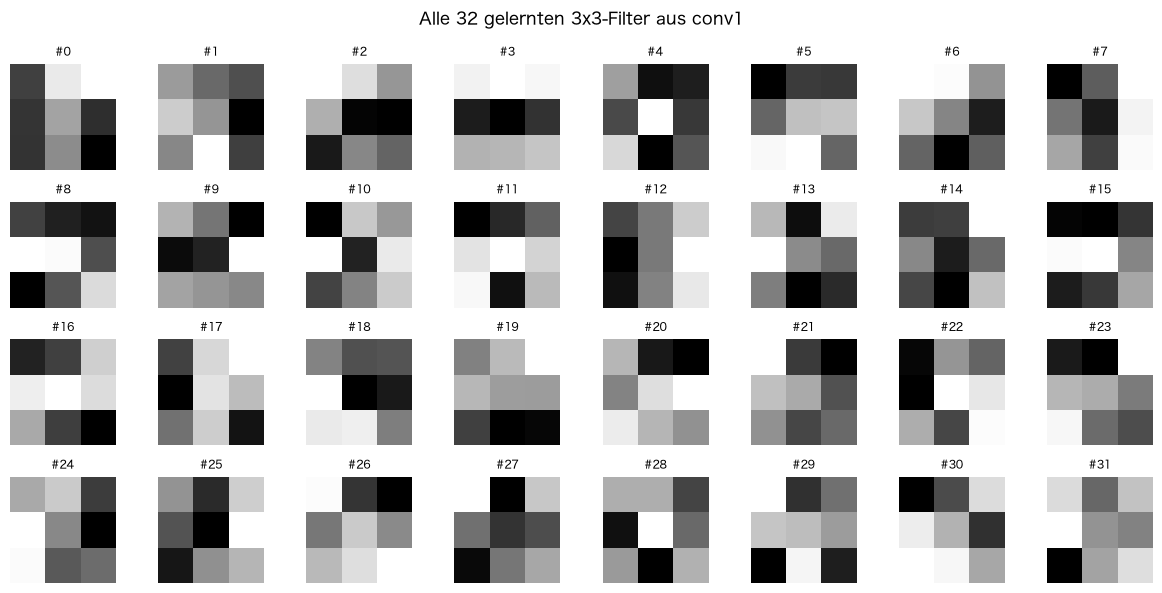

In [40]:
import matplotlib.pyplot as plt

filters = trained_model.conv1.weight.detach()  # shape (32, 1, 3, 3)

fig, axes = plt.subplots(4, 8, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(filters[i, 0], cmap="gray")
    ax.set_title(f"#{i}", fontsize=8)
    ax.axis("off")

plt.suptitle("Alle 32 gelernten 3x3-Filter aus conv1")
plt.tight_layout()
plt.show()

## Applying the 32 filters to a real character

Now not abstract anymore, but concrete: send a real image through `conv1` and look at all 32 resulting feature maps.

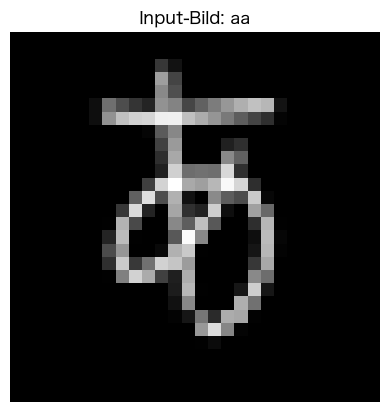

In [41]:
from data_loader import load_hiragana

X, y, classes = load_hiragana("../data/kaggle_hiragana")

sample_image = X[0]  # ein einzelnes 28x28 Bild, Werte 0-255
sample_label = classes[y[0]]

plt.imshow(sample_image, cmap="gray")
plt.title(f"Input-Bild: {sample_label}")
plt.axis("off")
plt.show()

Now actually send this one image through `conv1`. First it has to be reshaped into the form the layer expects: `(batch, channel, height, width)`, i.e. `(1, 1, 28, 28)` instead of the raw `(28, 28)`. The result is 32 feature maps (one per filter), still at the original 28x28 resolution (padding=1 doesn't change the size) and still **before** ReLU, so negative values can still occur here.

Shape vor conv1: torch.Size([1, 1, 28, 28])
Shape nach conv1: torch.Size([32, 28, 28])


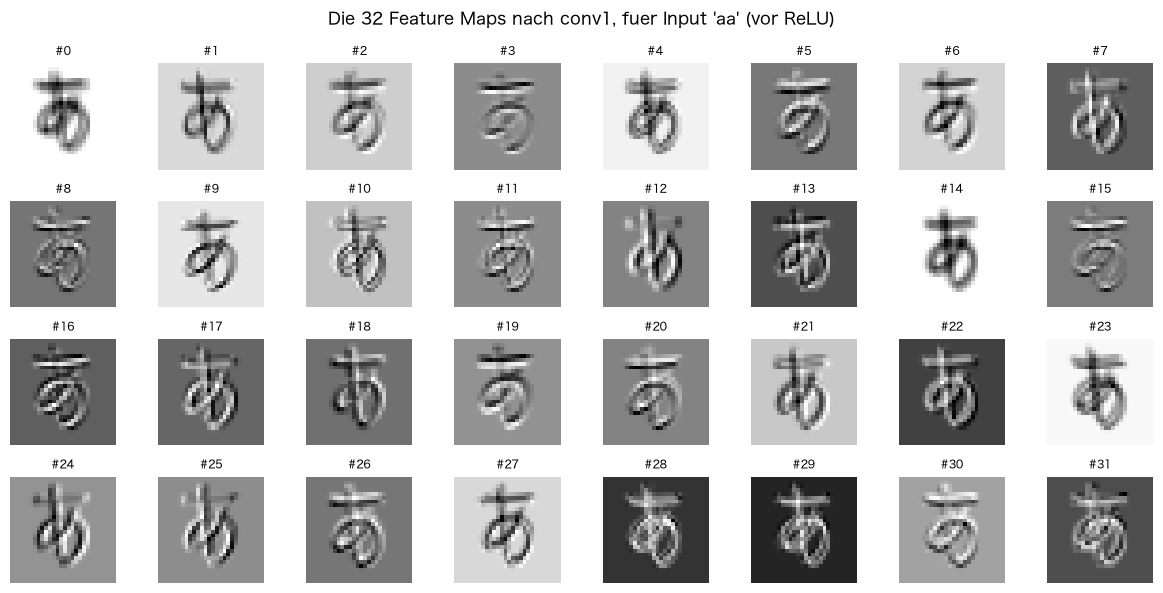

In [42]:
# Bild in das Format bringen, das conv1 erwartet: (Batch, Kanal, Hoehe, Breite)
img_tensor = torch.tensor(sample_image / 255.0, dtype=torch.float32)
img_tensor = img_tensor.unsqueeze(0).unsqueeze(0)  # (28,28) -> (1,1,28,28)
print("Shape vor conv1:", img_tensor.shape)

with torch.no_grad():
    feature_maps = trained_model.conv1(img_tensor)  # (1, 32, 28, 28)

feature_maps = feature_maps.squeeze(0)  # (32, 28, 28)
print("Shape nach conv1:", feature_maps.shape)

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(feature_maps[i], cmap="gray")
    ax.set_title(f"#{i}", fontsize=8)
    ax.axis("off")

plt.suptitle(f"Die 32 Feature Maps nach conv1, fuer Input '{sample_label}' (vor ReLU)")
plt.tight_layout()
plt.show()

### For comparison: the same feature maps after ReLU

Reminder from before: ReLU sets all negative values to 0 (= black). Compare with the image above.

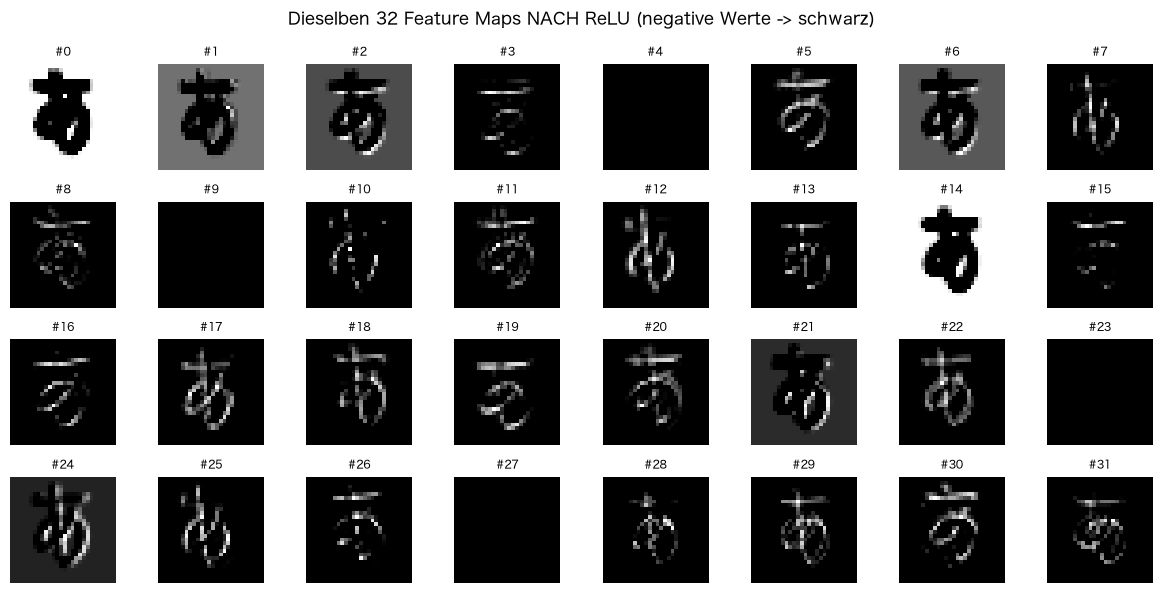

In [48]:
import torch.nn.functional as F

feature_maps_relu = F.relu(feature_maps)

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(feature_maps_relu[i], cmap="gray")
    ax.set_title(f"#{i}", fontsize=8)
    ax.axis("off")

plt.suptitle(f"Dieselben 32 Feature Maps NACH ReLU (negative Werte -> schwarz)")
plt.tight_layout()
plt.show()

## Filter pattern and result side by side

On top, the 3x3 pattern the filter is looking for; below, exactly where in the real image that pattern was found (after ReLU, so only the positive hits).

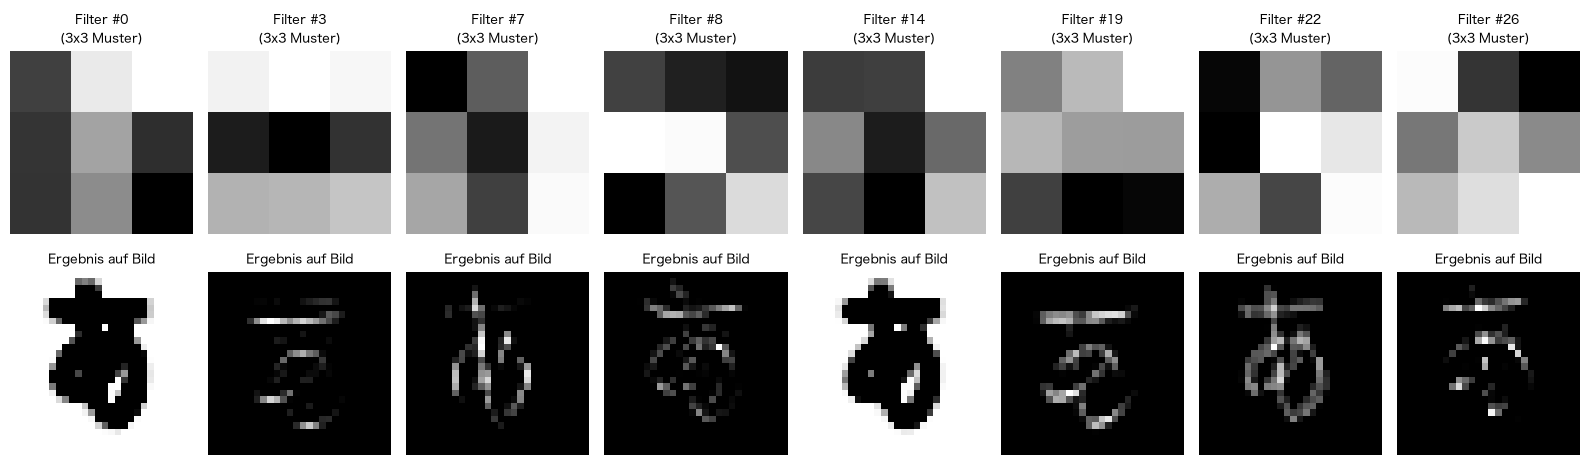

In [44]:
show_indices = [0, 3, 7, 8, 14, 19, 22, 26]

fig, axes = plt.subplots(2, len(show_indices), figsize=(16, 5))
for col, idx in enumerate(show_indices):
    axes[0, col].imshow(filters[idx, 0], cmap="gray")
    axes[0, col].set_title(f"Filter #{idx}\n(3x3 Muster)", fontsize=9)
    axes[0, col].axis("off")

    axes[1, col].imshow(feature_maps_relu[idx], cmap="gray")
    axes[1, col].set_title("Ergebnis auf Bild", fontsize=9)
    axes[1, col].axis("off")

plt.tight_layout()
plt.show()

## The same thing again for a kanji

For comparison: the same conv1 with the same 32 filters, but now applied to a kanji instead of a hiragana.

Note: matplotlib's default font can't render kanji (a display issue, not relevant to the model), so a font with Japanese support is set here.

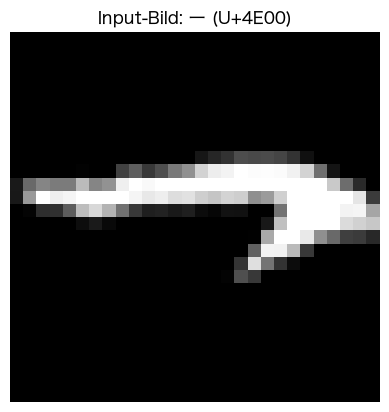

In [45]:
plt.rcParams["font.family"] = "Hiragino Sans"  # macOS-Schriftart mit Kanji-Unterstuetzung

from data_loader import load_kanji

X_kanji, y_kanji, kanji_classes = load_kanji("../data/kuzushiji_kanji/kkanji2")

sample_image_kanji = X_kanji[0]
sample_label_kanji = kanji_classes[y_kanji[0]]
sample_char_kanji = chr(int(sample_label_kanji[2:], 16))  # Unicode-Code -> Zeichen

plt.imshow(sample_image_kanji, cmap="gray")
plt.title(f"Input-Bild: {sample_char_kanji} ({sample_label_kanji})")
plt.axis("off")
plt.show()

Exactly the same process as before with "aa": convert the image to tensor form, through `conv1`, then ReLU. The interesting part is comparing the results: some filters react similarly to both character types (general edge detection), others differently, depending on how the strokes run.

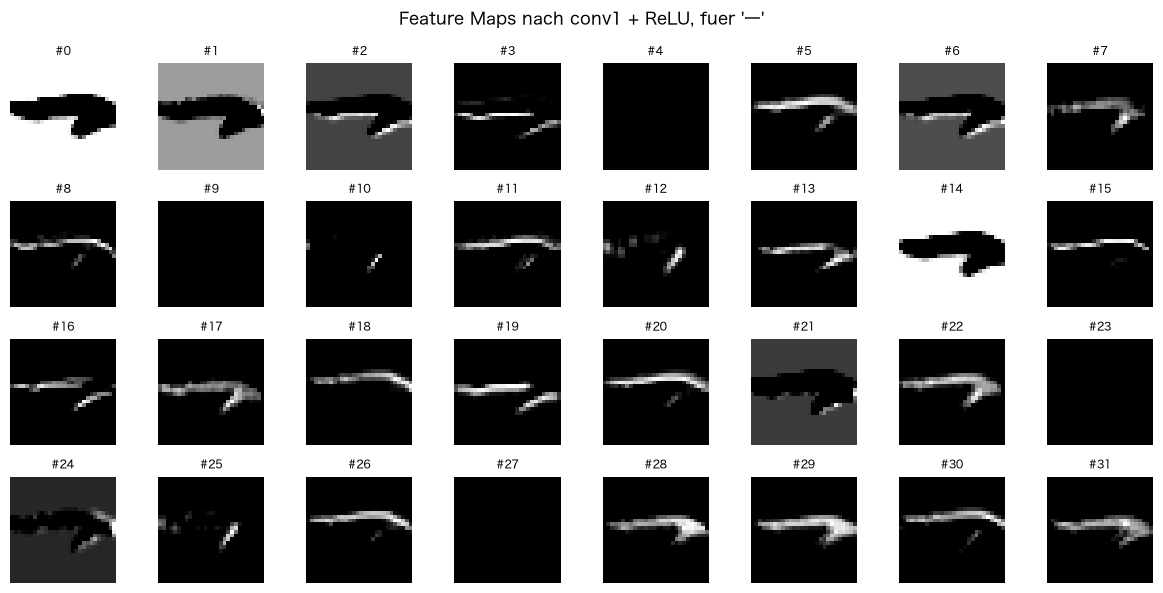

In [46]:
img_tensor_kanji = torch.tensor(sample_image_kanji / 255.0, dtype=torch.float32)
img_tensor_kanji = img_tensor_kanji.unsqueeze(0).unsqueeze(0)

with torch.no_grad():
    feature_maps_kanji = trained_model.conv1(img_tensor_kanji).squeeze(0)

feature_maps_kanji_relu = F.relu(feature_maps_kanji)

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(feature_maps_kanji_relu[i], cmap="gray")
    ax.set_title(f"#{i}", fontsize=8)
    ax.axis("off")

plt.suptitle(f"Feature Maps nach conv1 + ReLU, fuer '{sample_char_kanji}'")
plt.tight_layout()
plt.show()

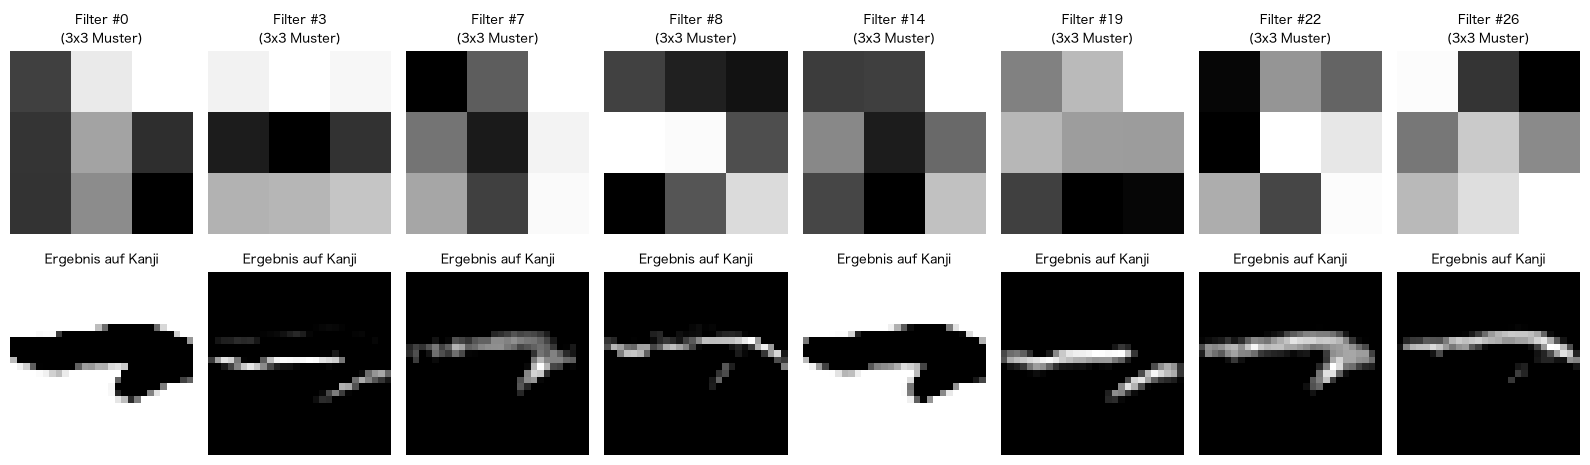

In [47]:
fig, axes = plt.subplots(2, len(show_indices), figsize=(16, 5))
for col, idx in enumerate(show_indices):
    axes[0, col].imshow(filters[idx, 0], cmap="gray")
    axes[0, col].set_title(f"Filter #{idx}\n(3x3 Muster)", fontsize=9)
    axes[0, col].axis("off")

    axes[1, col].imshow(feature_maps_kanji_relu[idx], cmap="gray")
    axes[1, col].set_title("Ergebnis auf Kanji", fontsize=9)
    axes[1, col].axis("off")

plt.tight_layout()
plt.show()